# Module3 Lab1 Homework For CS82A - Cleaning Messy Data
In this lab we will import messy data and run in through the steps dictated in the homework assignment to clean it and run some analyses.

In [2]:
import pandas as pd
df = pd.read_csv('messy_sales.csv')

In [3]:
df.shape

(300, 6)

In [9]:
df.head(10)

,order_id,date,product,price,qty,zip
0,1254,04/06/2026,mug,11.36,4,60614
1,1057,2026-05-30,charger,14.79,3,30303
2,1150,05/06/2026,mug,5.50,1,10001
3,1066,05/30/2026,notebook,NaN,1,98101
4,1114,04/06/2026,webcam,45.59,4,90405
5,1280,04/22/2026,pen set,NaN,4,30303
6,1204,04/18/2026,charger,8.41,2,2134
7,1249,2026-05-15,keyboard,75.04,4,90405
8,1037,2026-05-19,mug,9.31,2,60614
9,1177,2026-05-13,mug,10.11,3,90210


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   order_id  300 non-null    int64  
 1   date      300 non-null    str    
 2   product   300 non-null    str    
 3   price     288 non-null    float64
 4   qty       300 non-null    int64  
 5   zip       300 non-null    int64  
dtypes: float64(1), int64(3), str(2)
memory usage: 19.2 KB


In [6]:
df.describe()

,order_id,price,qty,zip
count,300.000000,288.000000,300.000000,300.000000
mean,1144.816667,56.068438,2.913333,45385.276667
std,84.515319,72.307182,1.560107,39345.608641
min,1000.000000,2.930000,-5.000000,2116.000000
25%,1071.750000,10.945000,2.000000,2134.000000
50%,1144.500000,37.530000,3.000000,30303.000000
75%,1217.250000,61.417500,4.000000,90210.000000
max,1291.000000,479.290000,5.000000,98101.000000


# List 3 problems already seen in the data

1. "date" is in different formats, mm/dd/yyyy and yyyy-mm-dd.
2. There are NA values for "price" in two rows (out of the first 10).
3. The "date" is labeled as dtype "string". dtype needs to be changed. It needs to be sortable as a date for data analysis purposes.
4. "qty" has a negative number as the min. "qty" cannot be negative for this dataset.
5. "zip" should be 5 numbers, and should be a string or object,not integer dtype.
6. "price" is 12 missing values. The count is 288 out of 300.
7. Max "price" may be too high. There is a big jump in the max value when compared to the min and percent breakdowns.

In [10]:
df.isna().sum() 

order_id     0
date         0
product      0
price       12
qty          0
zip          0
dtype: int64

<Axes: >

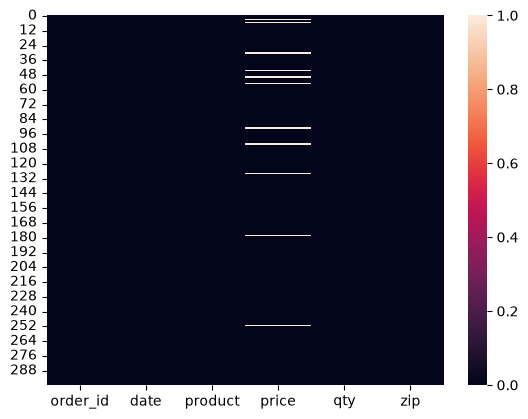

In [12]:
import seaborn as sns
sns.heatmap(df.isnull())

The "price" column is missing 12 values. They seem randomly located, so not file corruption. 

We do not know if these prices are for webcams, mugs, or something else. 

We should find out what is missing and take the mean value of that item and replace the missing value with the mean cost of the particular item.

If the price is missing (NA), then find the product type, calculate the average price for all of those prodcut types in the data set and assign that value as the missing values (product specific average price).

# I want to see what the products are for the NA prices.

Google prompt: How do I find out what rows in a dataset have NA in python

Google answer:
rows_with_na = df[df.isna().any(axis=1)]
print(rows_with_na)

In [15]:
rows_with_na = df[df.isna().any(axis=1)]
print(rows_with_na)

     order_id        date     product  price  qty    zip
3        1066  05/30/2026    notebook    NaN    1  98101
5        1280  04/22/2026     pen set    NaN    4  30303
30       1088  04/28/2026     pen set    NaN    2   2134
44       1101  2026-05-12    keyboard    NaN    3   2116
49       1199  2026-04-18     charger    NaN    5  30303
50       1018  05/04/2026     monitor    NaN    4  10001
55       1170  04/04/2026     monitor    NaN    1   2116
91       1040  05/08/2026     pen set    NaN    3   2134
104      1240  04/16/2026  headphones    NaN    1  60614
128      1261  2026-05-09   desk lamp    NaN    2  90405
178      1005  2026-05-24     monitor    NaN    2   2134
251      1155  2026-04-08     charger    NaN    3   2134


# Now I need the average price of notebook, pen set, keyboard, charger, monitor, headphones, desklamp

In [22]:
notebook_price = df[df["product"]== "notebook"]

In [25]:
print(notebook_price)

     order_id        date   product  price  qty    zip
3        1066  05/30/2026  notebook    NaN    1  98101
14       1273  2026-05-21  notebook   8.69    3  98101
37       1148  04/14/2026  notebook   7.08    4  30303
39       1168  05/23/2026  notebook   7.57    1  98101
45       1207  2026-04-14  notebook   9.37    4  60614
46       1138  05/25/2026  notebook   7.20    5   2134
54       1278  04/26/2026  notebook   6.56    4  10001
60       1022  05/07/2026  notebook   7.92    3   2134
89       1069  2026-04-18  notebook   2.93    4  60614
90       1036  04/08/2026  notebook   5.33    1  10001
92       1145  2026-05-19  notebook   4.87    5   2116
112      1139  2026-05-20  notebook   8.02    1  60614
114      1161  2026-05-06  notebook   6.78    3   2116
115      1194  04/16/2026  notebook   7.77    2   2134
131      1001  2026-05-02  notebook   3.03    4  30303
136      1095  2026-05-24  notebook   6.57    2   2134
138      1096  04/25/2026  notebook   6.58    5  30303
140      1

In [37]:
fill_value = notebook_price["price"].mean()
notebook_price["price"] = notebook_price["price"].fillna(fill_value)
print(notebook_price)
print(f"average notebook price {fill_value} dollars")
print(f"notebook price fill value is {fill_value} dollars")

     order_id        date   product      price  qty    zip
3        1066  05/30/2026  notebook   6.518077    1  98101
14       1273  2026-05-21  notebook   8.690000    3  98101
37       1148  04/14/2026  notebook   7.080000    4  30303
39       1168  05/23/2026  notebook   7.570000    1  98101
45       1207  2026-04-14  notebook   9.370000    4  60614
46       1138  05/25/2026  notebook   7.200000    5   2134
54       1278  04/26/2026  notebook   6.560000    4  10001
60       1022  05/07/2026  notebook   7.920000    3   2134
89       1069  2026-04-18  notebook   2.930000    4  60614
90       1036  04/08/2026  notebook   5.330000    1  10001
92       1145  2026-05-19  notebook   4.870000    5   2116
112      1139  2026-05-20  notebook   8.020000    1  60614
114      1161  2026-05-06  notebook   6.780000    3   2116
115      1194  04/16/2026  notebook   7.770000    2   2134
131      1001  2026-05-02  notebook   3.030000    4  30303
136      1095  2026-05-24  notebook   6.570000    2   21

#  Now the missing notebook price for Row 3 is the average notebook price for all the notebook data, 6.52. But that value has only been substituted in this "notebook_price" dataset, not the entire df.

In [38]:
penset_price = df[df["product"]== "pen set"]
ps_fill_value = penset_price["price"].mean()
penset_price["price"] = penset_price["price"].fillna(ps_fill_value)
print(penset_price)
print(f"average pen set price {ps_fill_value} dollars")
print(f"pen set price fill value is {ps_fill_value} dollars")

     order_id        date  product      price  qty    zip
5        1280  04/22/2026  pen set  10.648571    4  30303
30       1088  04/28/2026  pen set  10.648571    2   2134
43       1113  2026-04-27  pen set  15.270000    5  98101
75       1222  04/04/2026  pen set   4.910000    3  10001
88       1197  2026-05-13  pen set   9.620000    4  30303
91       1040  05/08/2026  pen set  10.648571    3   2134
100      1184  05/14/2026  pen set  13.450000    3  10001
123      1052  05/14/2026  pen set   9.930000    2   2116
125      1058  04/18/2026  pen set   7.680000    1  10001
129      1213  2026-04-27  pen set   7.710000    4   2134
130      1031  2026-05-12  pen set   7.760000    2   2116
135      1277  2026-05-27  pen set   9.710000    3   2134
146      1077  2026-05-15  pen set   6.680000    3  98101
151      1082  04/07/2026  pen set  13.340000    2   2116
174      1105  2026-05-18  pen set   8.010000    4  30303
181      1116  04/01/2026  pen set  13.490000    1  60614
188      1026 

# I would keep repeating this idea for all the product options with NA data values. However, this does not amend the original df. So it is not a good solution.